<a href="https://colab.research.google.com/github/sandeepgangaram/neural-nets/blob/master/makemor/makemor_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('./names.txt','r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [4]:
len(words)

32033

In [5]:
from IPython.core.crashhandler import crash_handler_lite
#build the vocabulary of characters and mappings to/from integers
chars = sorted(set(''.join(words)))
stoi = {char:i+1 for i,char in enumerate(chars)}
stoi['.'] = 0
itos = {i: char for char, i in stoi.items()}
# itos

In [6]:
block_size = 3 #context length - characters to predict next character

# build the dataset
def build_dataset(words):
  X, Y = [],[]

  for w in words:
    # print(w)
    context = [0]*block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context),'--->', itos[ix])
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape,Y.shape)
  return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])     #training set 80% - train parameters
Xdev, Ydev = build_dataset(words[n1:n2]) #dev/validation set 10% - train hyperparameters
Xte, Yte = build_dataset(words[n2:])     #test set 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
# putting it all together
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(27,10, generator=g)
W1 = torch.nn.init.kaiming_uniform_(torch.empty(30,400), mode="fan_in", nonlinearity="relu")
b1 = torch.randn(400, generator=g)

W2 = torch.nn.init.kaiming_uniform_(torch.empty(400,27), mode="fan_in", nonlinearity="relu")
b2 = torch.rand(27, generator=g)

# W1 = torch.rand(30,400, generator=g)
# W2 = torch.randn(400,27, generator=g)
parameters = [C,W1, W2, b1, b2]

In [8]:
sum(p.nelement() for p in parameters)
for p in parameters:
  p.requires_grad = True

In [9]:
lre = torch.linspace(-3,1,1000)
lrs = 10**lre


In [10]:
lri = []
lossi = []
stepsi = []

In [11]:

for i in range(300000):
  #mini-batch construct
  ix = torch.randint(0, Xtr.shape[0], (27,))

  #forward-pass
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1,30)@W1 + b1)
  logits = h@W2 + b2
  loss = F.cross_entropy(logits,Ytr[ix])

  #backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #learning reate decay - once loss plateus, reduce the learning rate /10
  lr = 0.001
  if(i < 100000):
    lr = 0.1
  elif(i < 200000):
    lr = 0.01

  for p in parameters:
    p.data -= lr*p.grad

  # lri.append(lre[i])
  stepsi.append(i)
  lossi.append(loss.log10().item())
# print(loss.item())


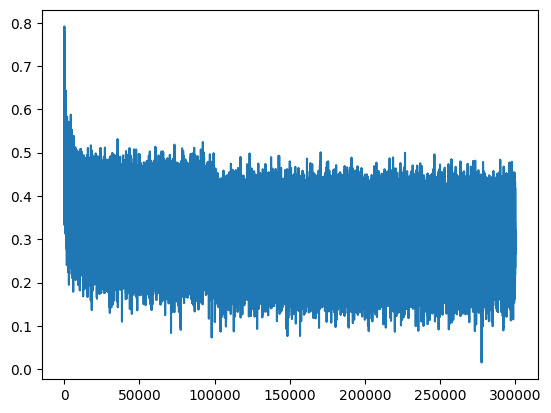

In [12]:
plt.plot(stepsi, lossi)

In [13]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30)@W1 + b1)
logits = h@W2 + b2
loss = F.cross_entropy(logits,Ytr)
loss.item()

2.030961513519287

In [14]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30)@W1 + b1)
logits = h@W2 + b2
loss = F.cross_entropy(logits,Ydev)
loss.item()

2.0909740924835205

In [15]:
# training loss ~ dev loss - "underfitting" - network is tiny
# plt.plot(lre, lossi)

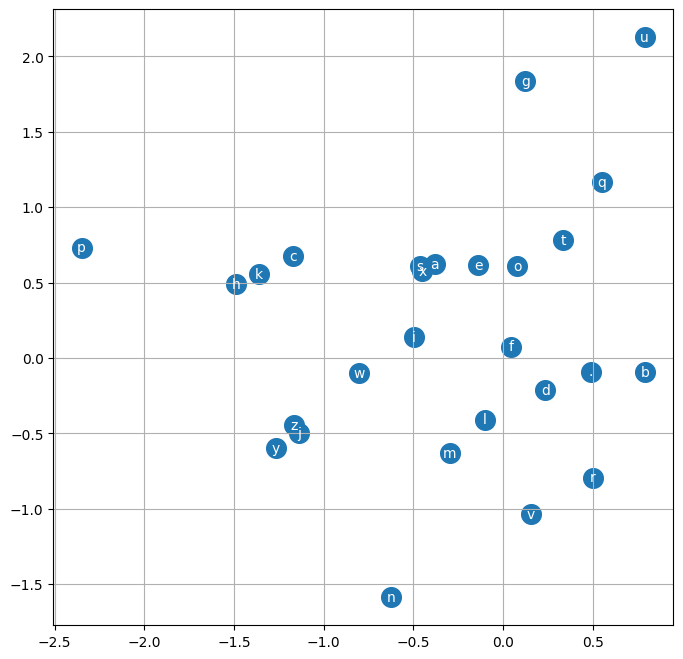

In [16]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data, s=200)
for i in range(C.shape[0]):
  plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')



In [17]:
C.shape

torch.Size([27, 10])

In [18]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))



celia.
moghanikio.
zary.
kell.
imitta.
noluwan.
katar.
samiyah.
javari.
mari.
molie.
cavorie.
teda.
kaley.
maside.
eniavion.
ratlyn.
huniven.
tahlan.
kashrudie.
